UPscaledEV Project BESS Test Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Readme:
This code aims at testing the optimization framework only with BESS. Once successful, structure will be applied to imp and baseline files.

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.

Set working path and import packages

In [1]:
import os
os.chdir('/Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024') 
print("Path is:", os.getcwd(), "\n")

import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
from pathlib import Path
import calendar
import holidays
import glob
import cvxpy as cp
import sys
import warnings
from tqdm import tqdm
import gurobipy as gp
import seaborn as sns

Path is: /Users/admin/Desktop/EV_program/Total Transfer/PowerFlex_Code/UPSCALeDEV_2024 



In [ ]:
# create weekdays (excluding holidays) and weekends (including holidays) lists
year = 2025
Holidays = holidays.US(years=year)
Holidays_dates = list(Holidays.keys())
Holidays_dates = [date for date in Holidays_dates if date.year == year]

start_ind_Y = datetime(year,1,1)
end_ind_Y = datetime(year+1,1,1)
DateSeries_ThisY = []
while start_ind_Y < end_ind_Y:
    DateSeries_ThisY.append(start_ind_Y)
    start_ind_Y += timedelta(hours=24)

DateSeries_ThisY = pd.Series(DateSeries_ThisY)
Y_Weekends = DateSeries_ThisY[DateSeries_ThisY.dt.dayofweek>=5]
Y_Holidays = DateSeries_ThisY[DateSeries_ThisY.dt.date.isin(Holidays_dates)]

Y_WeekendsWH = pd.concat([Y_Weekends,Y_Holidays],axis=0).drop_duplicates(keep='first', inplace=False).sort_values(axis=0, ascending=True).reset_index(drop=True)
Y_WeekdaysWOH = DateSeries_ThisY[~(DateSeries_ThisY.isin(Y_WeekendsWH))].sort_values(axis=0, ascending=True).reset_index(drop=True)
if len(Y_WeekdaysWOH) + len(Y_WeekendsWH) != len(DateSeries_ThisY):
    print("Error in holiday identification!\n")
    sys.exit()

Daily loop for testing BESS optimization

In [ ]:
# MPC parameters
dt_m_EV = 15
dt_h = dt_m_EV / 60
interval = timedelta(minutes = dt_m_EV)
c_BESS_penalty = 0.01  # penalty coefficient for BESS ramping
M = 1000  # large number for big-M method

# BESS parameters
SOC_BESS_min = 0.05
SOC_BESS_max = 0.95
P_BESS_max = 250                     # kW
C_BESS = 332                         # kWh
gamma = 0.9                          # efficiency # NOTE: use 0.9 later

test_month = 7
Cases = ['Base', 'Case1'] # not used here but for structure consistency
SOC_BESS_last_step = np.ones(len(Cases)) * 0.5  # initial SOC at 50%
SOC_BESS_daily_end = np.ones(len(Cases)) * 0.5

# Daily loop start
for month in np.arange(test_month, test_month + 1):  # (test_month, test_month + 1)
    print("Test month:", month)
    num_days = calendar.monthrange(year,month)[1] 
    Status_list_DA = []
  
    for Day in tqdm(np.arange(1, num_days + 1), desc="Processing days"): # (1, num_days + 1)
        revenue_WM_daily = np.zeros(2)
        revenue_DR_daily = np.zeros(2)
        
        TheDate_Day0 = datetime(year, month, Day)   
        TheDate_Day0_Start = TheDate_Day0 + timedelta(seconds=0)
        TheDate_Day0_End = TheDate_Day0 + timedelta(hours=24)
        
        if len(Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0])>0: 
            Order = Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekdaysWOH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekdaysWOH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekdaysWOH[Order-3].iloc[0]
        else:
            Order = Y_WeekendsWH[Y_WeekendsWH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekendsWH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekendsWH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekendsWH[Order-3].iloc[0]
            
        
        TheDate_Dayb1_Start = TheDate_Dayb1 + timedelta(seconds=0)
        TheDate_Dayb1_End   = TheDate_Dayb1 + timedelta(hours=24)
        TheDate_Dayb2_Start = TheDate_Dayb2 + timedelta(seconds=0)
        TheDate_Dayb2_End   = TheDate_Dayb2 + timedelta(hours=24)
        TheDate_Dayb3_Start = TheDate_Dayb3 + timedelta(seconds=0)
        TheDate_Dayb3_End   = TheDate_Dayb3 + timedelta(hours=24)

        TheDate        = [TheDate_Day0, TheDate_Dayb1, TheDate_Dayb2, TheDate_Dayb3]
        TheDates_Start = [TheDate_Day0_Start, TheDate_Dayb1_Start, TheDate_Dayb2_Start, TheDate_Dayb3_Start]
        TheDates_End   = [TheDate_Day0_End, TheDate_Dayb1_End, TheDate_Dayb2_End, TheDate_Dayb3_End]
        
        # Read the LMP data
        dir_Input_DA = os.path.join("2025Data/LMP/2025/DA/")
        dir_Input_RT = os.path.join("2025Data/LMP/2025/FM/")

        filename_Input = glob.glob(dir_Input_DA + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_DA = pd.read_csv(''.join(filename_Input))
        filename_Input = glob.glob(dir_Input_RT + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_RT = pd.read_csv(''.join(filename_Input))
                
        Data_LMP_DA = Data_LMP_DA[Data_LMP_DA['LMP_TYPE']=='LMP']
        Data_LMP_RT = Data_LMP_RT[Data_LMP_RT['LMP_TYPE']=='LMP']
        
        # sort the 'INTERVALSTARTTIME_GMT'
        LMP_IntervalStartGMT_DA = Data_LMP_DA['INTERVALSTARTTIME_GMT']
        LMP_IntervalStartGMT_RT = Data_LMP_RT['INTERVALSTARTTIME_GMT']
        
        # sort LMP data based on the 'INTERVALSTARTTIME_GMT'    
        A = pd.to_datetime(LMP_IntervalStartGMT_DA)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_DA_ = Data_LMP_DA.iloc[ LMPOrder, :]
        
        A = pd.to_datetime(LMP_IntervalStartGMT_RT)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_RT_ = Data_LMP_RT.iloc[ LMPOrder, :]
        
        Bid_Pr_DA = np.array(Data_LMP_DA_['MW'].repeat(4)*0.001) #repeat 4 times of the 24 x 1 series, $/MWh ---> $/kWh # NOTE: no reshape to 2-D array
        Bid_Pr_RT = (np.average(np.array(Data_LMP_RT_['VALUE']).reshape(-1, 3), axis=1)*0.001) #ave every 3 entries of the 288  x 1 series, $/MWh ---> $/kWh
        
        # Read the Ancillary Service prices data
        dir_AS_DA = os.path.join("2025Data/AS_DAM/")
        dir_AS_RT = os.path.join("2025Data/AS_RTM/")
        Data_AS_DA = pd.read_csv(dir_AS_DA + 'AS_price_2025_clear.csv')
        Data_AS_RT = pd.read_csv(dir_AS_RT + 'AS_price_2025_clear.csv')
        Data_AS_DA["datetime"] = pd.to_datetime(Data_AS_DA["datetime"])
        Data_AS_RT["datetime"] = pd.to_datetime(Data_AS_RT["datetime"])
        Data_AS_DA = Data_AS_DA[(Data_AS_DA["datetime"].dt.year == year) & (Data_AS_DA["datetime"].dt.month == test_month) & (Data_AS_DA["datetime"].dt.day == Day)].reset_index(drop=True)
        Data_AS_RT = Data_AS_RT[(Data_AS_RT["datetime"].dt.year == year) & (Data_AS_RT["datetime"].dt.month == test_month) & (Data_AS_RT["datetime"].dt.day == Day)].reset_index(drop=True)

        # Convert DA hourly AS prices to 15-min interval prices
        AS_Pr_RU_DA = np.repeat(Data_AS_DA["RegUp"].values, 4)
        AS_Pr_RD_DA = np.repeat(Data_AS_DA["RegDown"].values, 4)
        AS_Pr_SP_DA = np.repeat(Data_AS_DA["Spin"].values, 4)
        AS_Pr_NSP_DA = np.repeat(Data_AS_DA["NonSpin"].values, 4)

        # RT values does not need to be converted
        AS_Pr_RU_RT = Data_AS_RT["RegUp"].values
        AS_Pr_RD_RT = Data_AS_RT["RegDown"].values
        AS_Pr_SP_RT = Data_AS_RT["Spin"].values
        AS_Pr_NSP_RT = Data_AS_RT["NonSpin"].values
        
        # divide all by 1000 to convert $/MW to $/kW
        AS_Pr_RU_DA = AS_Pr_RU_DA * 0.001
        AS_Pr_RD_DA = AS_Pr_RD_DA * 0.001
        AS_Pr_SP_DA = AS_Pr_SP_DA * 0.001
        AS_Pr_NSP_DA = AS_Pr_NSP_DA * 0.001
        AS_Pr_RU_RT = AS_Pr_RU_RT * 0.001
        AS_Pr_RD_RT = AS_Pr_RD_RT * 0.001
        AS_Pr_SP_RT = AS_Pr_SP_RT * 0.001
        AS_Pr_NSP_RT = AS_Pr_NSP_RT * 0.001
        
        
        #################################################################################
        # VERSION: DA/Offline CVX Optimization
        #################################################################################
        H = 96
        
        Bid_Pr_DA_i = Bid_Pr_DA[:]
        Bid_Pr_RT_i = Bid_Pr_RT[:]
        AS_Pr_RU_DA_i = AS_Pr_RU_DA[:]
        AS_Pr_RD_DA_i = AS_Pr_RD_DA[:]
        AS_Pr_RU_RT_i = AS_Pr_RU_RT[:]
        AS_Pr_RD_RT_i = AS_Pr_RD_RT[:]
        AS_Pr_SP_DA_i = AS_Pr_SP_DA[:]
        AS_Pr_NSP_DA_i = AS_Pr_NSP_DA[:]
        AS_Pr_SP_RT_i = AS_Pr_SP_RT[:]
        AS_Pr_NSP_RT_i = AS_Pr_NSP_RT[:]
        
        # Construct the problem
        Cost_Opt = cp.Variable()
        penalty_BESS = 0
        
        # BESS variables # NOTE: use 1-D variables to reduce complexity and improve solving speed
        P_BESS = cp.Variable(H)         # net power
        P_BESS_pos = cp.Variable(H)     # charge (>=0)
        P_BESS_neg = cp.Variable(H)     # discharge (<=0)
        SOC_BESS = cp.Variable(H+1)     # SOC from 0 to H
        if Day == 1 and month == test_month:
            SOC_BESS_initial = 0.5
        else:
            SOC_BESS_initial = SOC_BESS_daily_end[0]  # use the final SOC of previous day in 100% eta as initial SOC of current day
        # Binary variable: 1 = charging, 0 = discharging
        z_BESS = cp.Variable(H, boolean=True)
        
        # WM constraints
        P_WM = cp.Variable(H)
        P_WM_DA_RU_bid = cp.Variable(H)
        P_WM_DA_RD_bid = cp.Variable(H)
        P_WM_RT_RU_bid = cp.Variable(H)
        P_WM_RT_RD_bid = cp.Variable(H)
        P_WM_DA_SP_bid = cp.Variable(H)
        P_WM_DA_NSP_bid = cp.Variable(H)
        P_WM_RT_SP_bid = cp.Variable(H)
        P_WM_RT_NSP_bid = cp.Variable(H)
        P_WM_DA_EM_bid = cp.Variable(H)
        P_WM_RT_EM_bid = cp.Variable(H)
        P_WM_DA_EM_pos = cp.Variable(H)
        P_WM_DA_EM_neg = cp.Variable(H)
        P_WM_RT_EM_pos = cp.Variable(H)
        P_WM_RT_EM_neg = cp.Variable(H)
        P_WM_pos = cp.Variable(H)
        P_WM_neg = cp.Variable(H)
        z_WM = cp.Variable(H, boolean=True)
        z_LMP = (Bid_Pr_RT >= 0).astype(int)  # NOTE: directly assign 0/1 based on RT LMP
        alpha_RU = 0.7 * z_LMP
        alpha_RD = 0.7 * (1 - z_LMP)
        alpha_SP = 0.2 * z_LMP
        alpha_NSP = 0.2 * z_LMP

        constraints_WM = [
            P_WM == -P_BESS,
            P_WM_pos >= 0,
            P_WM_pos <= M * z_WM,      # z=0 -> P_WM_pos = 0
            P_WM_neg <= 0,
            P_WM_neg >= -M * (1 - z_WM),  # z=1 -> P_WM_neg = 0
            P_WM == P_WM_pos + P_WM_neg,
            P_WM_DA_RU_bid >= 0,
            P_WM_RT_RU_bid >= 0,
            P_WM_DA_RD_bid <= 0,
            P_WM_RT_RD_bid <= 0,
            P_WM_DA_SP_bid >= 0,
            P_WM_RT_SP_bid >= 0,
            P_WM_DA_NSP_bid >= 0,
            P_WM_RT_NSP_bid >= 0,
            P_WM_DA_EM_pos >= 0,
            P_WM_DA_EM_neg <= 0,
            P_WM_RT_EM_pos >= 0,
            P_WM_RT_EM_neg <= 0,
            P_WM_DA_EM_bid == P_WM_DA_EM_pos + P_WM_DA_EM_neg,
            P_WM_RT_EM_bid == P_WM_RT_EM_pos + P_WM_RT_EM_neg
        ]

        # WM energy bid constraints
        rhs_pos = (
            cp.multiply(alpha_RU, P_WM_DA_RU_bid + P_WM_RT_RU_bid) +
            cp.multiply(alpha_SP, P_WM_DA_SP_bid + P_WM_RT_SP_bid) +
            cp.multiply(alpha_NSP, P_WM_DA_NSP_bid + P_WM_RT_NSP_bid) +
            P_WM_DA_EM_pos + P_WM_RT_EM_pos
        )
        rhs_neg = (
            cp.multiply(alpha_RD, P_WM_DA_RD_bid + P_WM_RT_RD_bid) +
            P_WM_DA_EM_neg + P_WM_RT_EM_neg
        )
        constraints_WM += [P_WM_pos >= rhs_pos, P_WM_neg <= rhs_neg]
        # WM capacity bid constraints
        rhs_pos = (
            P_WM_DA_RU_bid + P_WM_RT_RU_bid +
            P_WM_DA_SP_bid + P_WM_RT_SP_bid +
            P_WM_DA_NSP_bid + P_WM_RT_NSP_bid +
            P_WM_DA_EM_pos + P_WM_RT_EM_pos
        )
        rhs_neg = (
            P_WM_DA_RD_bid + P_WM_RT_RD_bid +
            P_WM_DA_EM_neg + P_WM_RT_EM_neg
        )
        constraints_WM += [P_WM_pos >= rhs_pos, P_WM_neg <= rhs_neg]

        # WM Revenue calculation
        Revenue_WM = (
            cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RU, (P_WM_DA_RU_bid + P_WM_RT_RU_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RD, (P_WM_DA_RD_bid + P_WM_RT_RD_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_SP, (P_WM_DA_SP_bid + P_WM_RT_SP_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_NSP, (P_WM_DA_NSP_bid + P_WM_RT_NSP_bid)))) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_DA_i, P_WM_DA_EM_bid)) * dt_h
            + cp.sum(cp.multiply(Bid_Pr_RT_i, P_WM_RT_EM_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_RU_DA_i, P_WM_DA_RU_bid)) * dt_h # NOTE: hourly revenue, so multiply by dt_h
            + cp.sum(cp.multiply(AS_Pr_RU_RT_i, P_WM_RT_RU_bid)) * dt_h
            - cp.sum(cp.multiply(AS_Pr_RD_DA_i, P_WM_DA_RD_bid)) * dt_h
            - cp.sum(cp.multiply(AS_Pr_RD_RT_i, P_WM_RT_RD_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_SP_DA_i, P_WM_DA_SP_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_SP_RT_i, P_WM_RT_SP_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_NSP_DA_i, P_WM_DA_NSP_bid)) * dt_h
            + cp.sum(cp.multiply(AS_Pr_NSP_RT_i, P_WM_RT_NSP_bid)) * dt_h
        )

        # Cost-related constraints
        constraints_cost = [
            Cost_Opt >= -Revenue_WM
        ]

        # BESS constraints
        constraints_bess = [
            P_BESS == P_BESS_pos + P_BESS_neg, # either positive or negative
            P_BESS_pos >= 0,
            P_BESS_neg <= 0,
            SOC_BESS[0] == SOC_BESS_initial,
            SOC_BESS[-1] == SOC_BESS_initial,  # without daily cycle termination, 2-day 1-way oscillation may occur
            SOC_BESS >= SOC_BESS_min,
            SOC_BESS <= SOC_BESS_max,
            SOC_BESS[1:] == SOC_BESS[:-1] + (dt_h / C_BESS) * (cp.multiply(P_BESS_pos, np.sqrt(gamma)) + cp.multiply(P_BESS_neg, 1 / np.sqrt(gamma))),
            dt_h * cp.sum(P_BESS_pos - P_BESS_neg) <= 2 * C_BESS,
            P_BESS_pos <= P_BESS_max * z_BESS,          # active only when charging
            P_BESS_neg >= -P_BESS_max * (1 - z_BESS)    # active only when discharging
        ]

        # soft penalty of battery usage
        penalty_BESS = (cp.norm(SOC_BESS[-1] - SOC_BESS_initial, 2)) * c_BESS_penalty # penalty coefficient

        # NOTE: Combine all constraints
        constraints = constraints_cost + constraints_bess + constraints_WM
        
        # Solve the problem
        Solver_Outputs_DA = {
            'Cost_Opt': [],
            'penalty_BESS': [],
            'Revenue_WM': [],
            'P_BESS_pos': [],
            'P_BESS_neg': [],
            'SOC_BESS': [],
            'z_BESS': [],
            'P_WM_pos': [],
            'P_WM_neg': [],
            'z_WM': [],
            'P_WM_DA_RU_bid': [],
            'P_WM_DA_RD_bid': [],
            'P_WM_DA_SP_bid': [],
            'P_WM_DA_NSP_bid': [],
            'P_WM_DA_EM_bid': [],
            'P_WM_RT_RU_bid': [],
            'P_WM_RT_RD_bid': [],
            'P_WM_RT_SP_bid': [],
            'P_WM_RT_NSP_bid': [],
            'P_WM_RT_EM_bid': [],
            'LMP_DA': Bid_Pr_DA,
            'LMP_RT': Bid_Pr_RT,
            'AS_Pr_RU_DA': AS_Pr_RU_DA,
            'AS_Pr_RU_RT': AS_Pr_RU_RT,
            'AS_Pr_RD_DA': AS_Pr_RD_DA,
            'AS_Pr_RD_RT': AS_Pr_RD_RT,
            'AS_Pr_SP_DA': AS_Pr_SP_DA,
            'AS_Pr_NSP_DA': AS_Pr_NSP_DA,
            'AS_Pr_SP_RT': AS_Pr_SP_RT,
            'AS_Pr_NSP_RT': AS_Pr_NSP_RT
        }

        objective = cp.Minimize(Cost_Opt + penalty_BESS)
        prob = cp.Problem(objective, constraints)
        result = prob.solve(solver=cp.GUROBI, verbose=False, MIPGap=1e-4, canon_backend='SCIPY', Threads=8, Presolve=1)
        status = prob.status
        Status_list_DA = Status_list_DA + [status]
        if status != 'optimal':
            print("DA optimization does not have an optimal solution!")
            sys.exit()
        
        # Save DA results            
        P_WM_DA_RU_bid_value_DA = P_WM_DA_RU_bid.value
        P_WM_DA_RD_bid_value_DA = P_WM_DA_RD_bid.value
        P_WM_DA_SP_bid_value_DA = P_WM_DA_SP_bid.value
        P_WM_DA_NSP_bid_value_DA = P_WM_DA_NSP_bid.value
        P_WM_DA_EM_bid_value_DA = P_WM_DA_EM_bid.value

        Solver_Outputs_DA['Cost_Opt'] = Cost_Opt.value.item()
        Solver_Outputs_DA['penalty_BESS'] = penalty_BESS.value.item()
        Solver_Outputs_DA['Revenue_WM'] = Revenue_WM.value.item()
        Solver_Outputs_DA['P_BESS_pos'] = P_BESS_pos.value.flatten() # NOTE: change to flatten()
        Solver_Outputs_DA['P_BESS_neg'] = P_BESS_neg.value.flatten()
        Solver_Outputs_DA['SOC_BESS'] = SOC_BESS.value.flatten()[1:]  # exclude the initial SOC
        Solver_Outputs_DA['z_BESS'] = z_BESS.value.flatten()
        Solver_Outputs_DA['P_WM_pos'] = P_WM_pos.value.flatten()
        Solver_Outputs_DA['P_WM_neg'] = P_WM_neg.value.flatten()
        Solver_Outputs_DA['z_WM'] = z_WM.value.flatten()
        Solver_Outputs_DA['P_WM_DA_RU_bid'] = P_WM_DA_RU_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_RD_bid'] = P_WM_DA_RD_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_SP_bid'] = P_WM_DA_SP_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_NSP_bid'] = P_WM_DA_NSP_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_DA_EM_bid'] = P_WM_DA_EM_bid_value_DA.flatten()
        Solver_Outputs_DA['P_WM_RT_RU_bid'] = P_WM_RT_RU_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_RD_bid'] = P_WM_RT_RD_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_SP_bid'] = P_WM_RT_SP_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_NSP_bid'] = P_WM_RT_NSP_bid.value.flatten()
        Solver_Outputs_DA['P_WM_RT_EM_bid'] = P_WM_RT_EM_bid.value.flatten()

        
        #################################################################################
        # VERSION: Real Time Optimization Implementation
        #################################################################################
        # Results saving variables # NOTE: new saving variables for RT
        Revenue_WM_value_RT = np.zeros((len(Cases), 96))
        Cost_Opt_value_RT = np.zeros((len(Cases), 96))
        P_BESS_pos_value_RT = np.zeros((len(Cases), 96))
        P_BESS_neg_value_RT = np.zeros((len(Cases), 96))
        SOC_BESS_value_RT = np.zeros((len(Cases), 96))
        z_BESS_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_RU_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_RD_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_SP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_NSP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_DA_EM_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_RU_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_RD_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_SP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_NSP_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_RT_EM_bid_value_RT = np.zeros((len(Cases), 96))
        P_WM_pos_value_RT = np.zeros((len(Cases), 96))
        P_WM_neg_value_RT = np.zeros((len(Cases), 96))
        z_WM_value_RT = np.zeros((len(Cases), 96))
        penalty_BESS_value_RT = np.zeros((len(Cases), 96))
        penalty_WM_value_RT = np.zeros((len(Cases), 96))
        E_BESS_throughput_RT = np.zeros((len(Cases), 97)) # store energy throughput, like SOC from 0 to 97

        # Shrinking horizon implementation
        Status_list_imp = [[] for _ in range(len(Cases))]
        Solver_Outputs_RT = [[] for _ in range(len(Cases))]

        for i in range(len(Cases)):
            Solver_Outputs_RT[i] = {
                'Cost_Opt': [],
                'penalty_BESS': [],
                'penalty_WM': [],
                'Revenue_WM': [],
                'P_BESS_pos': [],
                'P_BESS_neg': [],
                'SOC_BESS': [],
                'z_BESS': [],
                'P_WM_pos': [],
                'P_WM_neg': [],
                'z_WM': [],
                'P_WM_DA_RU_bid': [],
                'P_WM_DA_RD_bid': [],
                'P_WM_DA_SP_bid': [],
                'P_WM_DA_NSP_bid': [],
                'P_WM_DA_EM_bid': [],
                'P_WM_RT_RU_bid': [],
                'P_WM_RT_RD_bid': [],
                'P_WM_RT_SP_bid': [],
                'P_WM_RT_NSP_bid': [],
                'P_WM_RT_EM_bid': []
            }

        
        for i_t in range(int(24/dt_h)):
            H = int(24/dt_h - i_t)  # Horizon, numb of time slots
            
            for i in range(len(Cases)):
                # 1-D array with length H = 96 - i_t
                Bid_Pr_DA_i = Bid_Pr_DA[i_t:]
                Bid_Pr_RT_i = Bid_Pr_RT[i_t:]
                AS_Pr_RU_DA_i = AS_Pr_RU_DA[i_t:]
                AS_Pr_RD_DA_i = AS_Pr_RD_DA[i_t:]
                AS_Pr_RU_RT_i = AS_Pr_RU_RT[i_t:]
                AS_Pr_RD_RT_i = AS_Pr_RD_RT[i_t:]
                AS_Pr_SP_DA_i = AS_Pr_SP_DA[i_t:]
                AS_Pr_NSP_DA_i = AS_Pr_NSP_DA[i_t:]
                AS_Pr_SP_RT_i = AS_Pr_SP_RT[i_t:]
                AS_Pr_NSP_RT_i = AS_Pr_NSP_RT[i_t:]
                
                # Construct the problem
                # NOTE: replace the full variables creation with new variables at each time
                Cost_Opt = cp.Variable() # scalar
                penalty_WM = 0
                penalty_BESS = 0

                # BESS variables
                P_BESS = cp.Variable(H)      # net power
                P_BESS_pos = cp.Variable(H)   # charge (>=0)
                P_BESS_neg = cp.Variable(H)   # discharge (<=0)
                SOC_BESS = cp.Variable(H+1)   # SOC from 0 to H (H+1 to include initial SOC)
                z_BESS = cp.Variable(H, boolean=True)  # charge/discharge mode indicator

                # WM variables
                z_LMP = (Bid_Pr_RT_i >= 0).astype(int)
                alpha_RU = 0.7 * z_LMP
                alpha_RD = 0.7 * (1 - z_LMP)
                alpha_SP = 0.2 * z_LMP
                alpha_NSP = 0.2 * z_LMP
                P_WM = cp.Variable(H)
                P_WM_RT_RU_bid = cp.Variable(H)
                P_WM_RT_RD_bid = cp.Variable(H)
                P_WM_RT_SP_bid = cp.Variable(H)
                P_WM_RT_NSP_bid = cp.Variable(H)
                P_WM_RT_EM_bid = cp.Variable(H)
                P_WM_DA_RU_bid = cp.Variable(H)
                P_WM_DA_RD_bid = cp.Variable(H)
                P_WM_DA_SP_bid = cp.Variable(H)
                P_WM_DA_NSP_bid = cp.Variable(H)
                P_WM_DA_EM_bid = cp.Variable(H)
                P_WM_DA_EM_pos = cp.Variable(H)
                P_WM_DA_EM_neg = cp.Variable(H)
                P_WM_RT_EM_pos = cp.Variable(H)
                P_WM_RT_EM_neg = cp.Variable(H)
                P_WM_pos = cp.Variable(H)
                P_WM_neg = cp.Variable(H)
                z_WM = cp.Variable(H, boolean=True)

                # SOC initialization
                if i_t == 0:
                    if Day == 1 and month == test_month:
                        SOC_BESS_initial = 0.5
                    else:
                        SOC_BESS_initial = SOC_BESS_daily_end[i]
                else:
                    SOC_BESS_initial = SOC_BESS_last_step[i]
                    
                # --- WM constraints ---
                constraints_WM = [
                    P_WM == -P_BESS,
                    P_WM_pos >= 0,
                    P_WM_pos <= M * z_WM,      # z=0 -> P_WM_pos = 0 # NOTE: use M not 10 * M
                    P_WM_neg <= 0,
                    P_WM_neg >= -M * (1 - z_WM),  # z=1 -> P_WM_neg = 0
                    P_WM == P_WM_pos + P_WM_neg,
                    P_WM_DA_RU_bid >= 0,
                    P_WM_RT_RU_bid >= 0,
                    P_WM_DA_RD_bid <= 0,
                    P_WM_RT_RD_bid <= 0,
                    P_WM_DA_SP_bid >= 0,
                    P_WM_RT_SP_bid >= 0,
                    P_WM_DA_NSP_bid >= 0,
                    P_WM_RT_NSP_bid >= 0,
                    P_WM_DA_EM_pos >= 0,
                    P_WM_DA_EM_neg <= 0,
                    P_WM_RT_EM_pos >= 0,
                    P_WM_RT_EM_neg <= 0,
                    P_WM_DA_EM_bid == P_WM_DA_EM_pos + P_WM_DA_EM_neg,
                    P_WM_RT_EM_bid == P_WM_RT_EM_pos + P_WM_RT_EM_neg
                    #P_WM_DA_RU_bid == P_WM_DA_RU_bid_value_DA[i_t:],
                    #P_WM_DA_RD_bid == P_WM_DA_RD_bid_value_DA[i_t:],
                    #P_WM_DA_SP_bid == P_WM_DA_SP_bid_value_DA[i_t:],
                    #P_WM_DA_NSP_bid == P_WM_DA_NSP_bid_value_DA[i_t:],
                    #P_WM_DA_EM_bid == P_WM_DA_EM_bid_value_DA[i_t:]
                ]
                # NOTE: soft constraints to follow DA bids, in $
                penalty_WM = cp.sum(cp.multiply(
                    np.abs(Bid_Pr_RT_i),
                    cp.abs(P_WM_DA_RU_bid  - P_WM_DA_RU_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_RD_bid  - P_WM_DA_RD_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_SP_bid  - P_WM_DA_SP_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_NSP_bid - P_WM_DA_NSP_bid_value_DA[i_t:])
                    + cp.abs(P_WM_DA_EM_bid  - P_WM_DA_EM_bid_value_DA[i_t:])
                ))

                '''
                # NOTE: soft constraints to avoid multiple solutions, in $
                penalty_WM += cp.sum(cp.multiply(
                    np.abs(Bid_Pr_RT_i),
                    cp.abs(P_WM_RT_RU_bid  - Solver_Outputs_DA['P_WM_RT_RU_bid'][i_t:])
                    + cp.abs(P_WM_RT_RD_bid  - Solver_Outputs_DA['P_WM_RT_RD_bid'][i_t:])
                    + cp.abs(P_WM_RT_SP_bid  - Solver_Outputs_DA['P_WM_RT_SP_bid'][i_t:])
                    + cp.abs(P_WM_RT_NSP_bid - Solver_Outputs_DA['P_WM_RT_NSP_bid'][i_t:])
                    + cp.abs(P_WM_RT_EM_bid  - Solver_Outputs_DA['P_WM_RT_EM_bid'][i_t:])
                ))
                '''
                
                # WM energy bid constraints
                rhs_pos = (
                    cp.multiply(alpha_RU, P_WM_DA_RU_bid + P_WM_RT_RU_bid) +
                    cp.multiply(alpha_SP, P_WM_DA_SP_bid + P_WM_RT_SP_bid) +
                    cp.multiply(alpha_NSP, P_WM_DA_NSP_bid + P_WM_RT_NSP_bid) +
                    P_WM_DA_EM_pos + P_WM_RT_EM_pos
                )
                rhs_neg = (
                    cp.multiply(alpha_RD, P_WM_DA_RD_bid + P_WM_RT_RD_bid) +
                    P_WM_DA_EM_neg + P_WM_RT_EM_neg
                )
                constraints_WM += [P_WM_pos >= rhs_pos, P_WM_neg <= rhs_neg]   
                # WM capacity bid constraints
                rhs_pos = (
                    P_WM_DA_RU_bid + P_WM_RT_RU_bid +
                    P_WM_DA_SP_bid + P_WM_RT_SP_bid +
                    P_WM_DA_NSP_bid + P_WM_RT_NSP_bid +
                    P_WM_DA_EM_pos + P_WM_RT_EM_pos
                )
                rhs_neg = (
                    P_WM_DA_RD_bid + P_WM_RT_RD_bid +
                    P_WM_DA_EM_neg + P_WM_RT_EM_neg
                )
                constraints_WM += [P_WM_pos >= rhs_pos, P_WM_neg <= rhs_neg]

                # WM Revenue calculation # TODO: for i_t each 4 times the P values should be the same that bid is hourly      
                Revenue_WM = (
                    cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RU, (P_WM_DA_RU_bid + P_WM_RT_RU_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_RD, (P_WM_DA_RD_bid + P_WM_RT_RD_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_SP, (P_WM_DA_SP_bid + P_WM_RT_SP_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, cp.multiply(alpha_NSP, (P_WM_DA_NSP_bid + P_WM_RT_NSP_bid)))) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_DA_i, P_WM_DA_EM_bid)) * dt_h
                    + cp.sum(cp.multiply(Bid_Pr_RT_i, P_WM_RT_EM_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_RU_DA_i, P_WM_DA_RU_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_RU_RT_i, P_WM_RT_RU_bid)) * dt_h
                    - cp.sum(cp.multiply(AS_Pr_RD_DA_i, P_WM_DA_RD_bid)) * dt_h
                    - cp.sum(cp.multiply(AS_Pr_RD_RT_i, P_WM_RT_RD_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_SP_DA_i, P_WM_DA_SP_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_SP_RT_i, P_WM_RT_SP_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_NSP_DA_i, P_WM_DA_NSP_bid)) * dt_h
                    + cp.sum(cp.multiply(AS_Pr_NSP_RT_i, P_WM_RT_NSP_bid)) * dt_h
                )
                
                # BESS constraints
                constraints_bess = [
                    P_BESS == P_BESS_pos + P_BESS_neg, # can be positive or negative
                    P_BESS_pos >= 0,
                    P_BESS_neg <= 0,
                    SOC_BESS[0] == SOC_BESS_initial,
                    SOC_BESS[-1] == SOC_BESS_daily_end[i],
                    SOC_BESS_min <= SOC_BESS,
                    SOC_BESS <= SOC_BESS_max,
                    SOC_BESS[1:] == SOC_BESS[:-1] + (dt_h / C_BESS) * (
                        cp.multiply(P_BESS_pos, np.sqrt(gamma)) + cp.multiply(P_BESS_neg, 1 / np.sqrt(gamma))
                    ),
                    dt_h * cp.sum(P_BESS_pos - P_BESS_neg) + E_BESS_throughput_RT[i, i_t] <= 2 * C_BESS, # NOTE: in RT the horizon is getting smaller, so past energy throughput should be considered
                    P_BESS_pos <= P_BESS_max * z_BESS,
                    P_BESS_neg >= -P_BESS_max * (1 - z_BESS)
                ]
                
                # soft penalty of battery usage
                penalty_BESS = (cp.norm(SOC_BESS[-1] - SOC_BESS_daily_end[i], 2)) * c_BESS_penalty

                # Cost related constraints
                constraints_cost = [
                    Cost_Opt >= -Revenue_WM
                ]
                # NOTE: combine all constraints
                constraints = constraints_cost + constraints_bess + constraints_WM
                
                objective = cp.Minimize(Cost_Opt + penalty_WM + penalty_BESS)
                prob = cp.Problem(objective, constraints)
                result = prob.solve(solver=cp.GUROBI, verbose=False, MIPGap=1e-4, canon_backend='SCIPY', Threads=8, warm_start=True, Presolve=1)
                status = prob.status
                Status_list_imp[i] = Status_list_imp[i] + [status]
                if status != 'optimal':
                    print("RT optimization does not have an optimal solution!")
                    sys.exit()
                    
                # Save each step RT result
                revenue_WM_i_t = (
                    Bid_Pr_RT_i[0] * alpha_RU[0] * (P_WM_DA_RU_bid.value[0] + P_WM_RT_RU_bid.value[0]) * dt_h
                    + Bid_Pr_RT_i[0] * alpha_RD[0] * (P_WM_DA_RD_bid.value[0] + P_WM_RT_RD_bid.value[0]) * dt_h
                    + Bid_Pr_RT_i[0] * alpha_SP[0] * (P_WM_DA_SP_bid.value[0] + P_WM_RT_SP_bid.value[0]) * dt_h
                    + Bid_Pr_RT_i[0] * alpha_NSP[0] * (P_WM_DA_NSP_bid.value[0] + P_WM_RT_NSP_bid.value[0]) * dt_h
                    + Bid_Pr_DA_i[0] * P_WM_DA_EM_bid.value[0] * dt_h
                    + Bid_Pr_RT_i[0] * P_WM_RT_EM_bid.value[0] * dt_h
                    + AS_Pr_RU_DA_i[0] * P_WM_DA_RU_bid.value[0] * dt_h
                    + AS_Pr_RU_RT_i[0] * P_WM_RT_RU_bid.value[0] * dt_h
                    - AS_Pr_RD_DA_i[0] * P_WM_DA_RD_bid.value[0] * dt_h
                    - AS_Pr_RD_RT_i[0] * P_WM_RT_RD_bid.value[0] * dt_h
                    + AS_Pr_SP_DA_i[0] * P_WM_DA_SP_bid.value[0] * dt_h
                    + AS_Pr_SP_RT_i[0] * P_WM_RT_SP_bid.value[0] * dt_h
                    + AS_Pr_NSP_DA_i[0] * P_WM_DA_NSP_bid.value[0] * dt_h
                    + AS_Pr_NSP_RT_i[0] * P_WM_RT_NSP_bid.value[0] * dt_h
                )
                
                SOC_BESS_last_step[i] = SOC_BESS.value[1]
                Revenue_WM_value_RT[i, i_t] = revenue_WM_i_t.item()
                Cost_Opt_value_RT[i, i_t] = Cost_Opt.value.item()
                P_BESS_pos_value_RT[i, i_t] = P_BESS_pos.value[0]
                P_BESS_neg_value_RT[i, i_t] = P_BESS_neg.value[0]
                SOC_BESS_value_RT[i, i_t] = SOC_BESS.value[1]
                z_BESS_value_RT[i, i_t] = z_BESS.value[0]
                P_WM_DA_RU_bid_value_RT[i, i_t] = P_WM_DA_RU_bid.value[0]
                P_WM_DA_RD_bid_value_RT[i, i_t] = P_WM_DA_RD_bid.value[0]
                P_WM_DA_SP_bid_value_RT[i, i_t] = P_WM_DA_SP_bid.value[0]
                P_WM_DA_NSP_bid_value_RT[i, i_t] = P_WM_DA_NSP_bid.value[0]
                P_WM_DA_EM_bid_value_RT[i, i_t] = P_WM_DA_EM_bid.value[0]
                P_WM_RT_RU_bid_value_RT[i, i_t] = P_WM_RT_RU_bid.value[0]
                P_WM_RT_RD_bid_value_RT[i, i_t] = P_WM_RT_RD_bid.value[0]
                P_WM_RT_SP_bid_value_RT[i, i_t] = P_WM_RT_SP_bid.value[0]
                P_WM_RT_NSP_bid_value_RT[i, i_t] = P_WM_RT_NSP_bid.value[0]
                P_WM_RT_EM_bid_value_RT[i, i_t] = P_WM_RT_EM_bid.value[0]
                P_WM_pos_value_RT[i, i_t] = P_WM_pos.value[0]
                P_WM_neg_value_RT[i, i_t] = P_WM_neg.value[0]
                z_WM_value_RT[i, i_t] = z_WM.value[0]
                penalty_BESS_value_RT[i, i_t] = penalty_BESS.value.item()
                penalty_WM_value_RT[i, i_t] = penalty_WM.value.item()
                E_BESS_throughput_RT[i, i_t+1] = E_BESS_throughput_RT[i, i_t] + dt_h * (P_BESS_pos.value[0] - P_BESS_neg.value[0])

            # end of loop i in Cases
        # end of loop i_t
        
        # Save all RT results
        for i in range(len(Cases)):
            Solver_Outputs_RT[i]['Cost_Opt'] = Cost_Opt_value_RT[i].flatten()
            Solver_Outputs_RT[i]['penalty_BESS'] = penalty_BESS_value_RT[i].flatten()
            Solver_Outputs_RT[i]['penalty_WM'] = penalty_WM_value_RT[i].flatten()
            Solver_Outputs_RT[i]['Revenue_WM'] = Revenue_WM_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_BESS_pos'] = P_BESS_pos_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_BESS_neg'] = P_BESS_neg_value_RT[i].flatten()
            Solver_Outputs_RT[i]['SOC_BESS'] = SOC_BESS_value_RT[i].flatten()
            Solver_Outputs_RT[i]['z_BESS'] = z_BESS_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_pos'] = P_WM_pos_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_neg'] = P_WM_neg_value_RT[i].flatten()
            Solver_Outputs_RT[i]['z_WM'] = z_WM_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_RU_bid'] = P_WM_DA_RU_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_RD_bid'] = P_WM_DA_RD_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_SP_bid'] = P_WM_DA_SP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_NSP_bid'] = P_WM_DA_NSP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_DA_EM_bid'] = P_WM_DA_EM_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_RU_bid'] = P_WM_RT_RU_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_RD_bid'] = P_WM_RT_RD_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_SP_bid'] = P_WM_RT_SP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_NSP_bid'] = P_WM_RT_NSP_bid_value_RT[i].flatten()
            Solver_Outputs_RT[i]['P_WM_RT_EM_bid'] = P_WM_RT_EM_bid_value_RT[i].flatten()

        Solver_Outputs_RT_Base = Solver_Outputs_RT[0]  # 100% eta for implementation

        # NOTE: Plotting prices and capacities for DA and RT
        palette = plt.get_cmap('tab10').colors
        # The total prices for each product, and Revenue_WM = sum of (price * capacity)
        price_RU_DA = Bid_Pr_RT * alpha_RU * dt_h + AS_Pr_RU_DA * dt_h
        price_RU_RT = Bid_Pr_RT * alpha_RU * dt_h + AS_Pr_RU_RT * dt_h
        price_RD_DA = Bid_Pr_RT * alpha_RD * dt_h - AS_Pr_RD_DA * dt_h
        price_RD_RT = Bid_Pr_RT * alpha_RD * dt_h - AS_Pr_RD_RT * dt_h
        price_SP_DA = Bid_Pr_RT * alpha_SP * dt_h + AS_Pr_SP_DA * dt_h
        price_SP_RT = Bid_Pr_RT * alpha_SP * dt_h + AS_Pr_SP_RT * dt_h
        price_NSP_DA = Bid_Pr_RT * alpha_NSP * dt_h + AS_Pr_NSP_DA * dt_h
        price_NSP_RT = Bid_Pr_RT * alpha_NSP * dt_h + AS_Pr_NSP_RT * dt_h
        price_EM_DA = Bid_Pr_DA * dt_h
        price_EM_RT = Bid_Pr_RT * dt_h

        time_index_RT = pd.date_range(start=TheDate_Day0, periods=96, freq='15min')  # 96 intervals
        t_RT = np.arange(len(time_index_RT))
        ticks = [0, 24, 48, 72]  # indices along compressed axis
        tick_labels = [
            (time_index_RT[0] + pd.Timedelta(minutes=15*x)).strftime('%m-%d-%Hh') for x in [0, 24, 48, 72]
        ]
        label_fontsize = 12
        title_fontsize = 14
        tick_fontsize = 10
        n_rows = 3
        plt.figure(figsize=(20, 4 * n_rows))
        plt.subplot(n_rows, 1, 1)
        plt.plot(t_RT, price_RU_DA, label='Price RU DA', color=palette[0], linestyle='--')
        plt.plot(t_RT, price_RU_RT, label='Price RU RT', color=palette[0], linestyle='-')
        plt.plot(t_RT, price_RD_DA, label='Price RD DA', color=palette[1], linestyle='--')
        plt.plot(t_RT, price_RD_RT, label='Price RD RT', color=palette[1], linestyle='-')
        plt.plot(t_RT, price_SP_DA, label='Price SP DA', color=palette[2], linestyle='--')
        plt.plot(t_RT, price_SP_RT, label='Price SP RT', color=palette[2], linestyle='-')
        plt.plot(t_RT, price_NSP_DA, label='Price NSP DA', color=palette[3], linestyle='--')
        plt.plot(t_RT, price_NSP_RT, label='Price NSP RT', color=palette[3], linestyle='-')
        plt.plot(t_RT, price_EM_DA, label='Price EM DA', color=palette[4], linestyle='--')
        plt.plot(t_RT, price_EM_RT, label='Price EM RT', color=palette[4], linestyle='-')
        plt.xticks(ticks, tick_labels, rotation=45, fontsize=tick_fontsize)
        plt.title('Total Prices over Time', fontsize=title_fontsize)
        plt.xlabel('Time', fontsize=label_fontsize)
        plt.ylabel('Total Price (to $/kW)', fontsize=label_fontsize)
        plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
        plt.grid(axis ='y')
        plt.subplot(n_rows, 1, 2)
        wm_bid_labels = [
            'P_WM_DA_RU_bid', 'P_WM_DA_RD_bid', 'P_WM_DA_SP_bid', 'P_WM_DA_NSP_bid', 'P_WM_DA_EM_bid',
            'P_WM_RT_RU_bid', 'P_WM_RT_RD_bid', 'P_WM_RT_SP_bid', 'P_WM_RT_NSP_bid', 'P_WM_RT_EM_bid'
        ]
        # keep only nonzero series
        data_dict = {
            label: Solver_Outputs_RT_Base[label]
            for label in wm_bid_labels
            if np.any(Solver_Outputs_RT_Base[label] != 0)
        }
        labels = list(data_dict.keys())
        colors = palette[:len(labels)]
        bottom = np.zeros_like(t_RT, dtype=float)
        for label, color in zip(labels, colors):
            values = data_dict[label]
            plt.bar(
                t_RT,
                values,
                bottom=bottom,
                width=dt_h * 1.5,
                label=label,
                color=color
            )
            bottom += values
        plt.axhline(0, linestyle=':')
        plt.ylim(bottom.min() * 1.1, bottom.max() * 1.1)
        plt.xticks(ticks, tick_labels, rotation=45, fontsize=tick_fontsize)
        plt.xlabel('Time', fontsize=label_fontsize)
        plt.ylabel('Bid Capacity (kW)', fontsize=label_fontsize)
        plt.title('Stacked Non-zero Bid Capacities (kW)', fontsize=title_fontsize)
        plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
        plt.grid(axis='y')
        ax1 = plt.subplot(n_rows, 1, 3)
        ax1.bar(t_RT, Solver_Outputs_RT_Base['P_BESS_pos'], label='P_BESS_pos_RT', color=palette[0], width=dt_h * 1.5)
        ax1.bar(t_RT, Solver_Outputs_RT_Base['P_BESS_neg'], label='P_BESS_neg_RT', color=palette[2], width=dt_h * 1.5)
        ax1.set_ylabel('Power (kW)', fontsize=label_fontsize)
        ax1.grid(axis='y')
        ax1.set_xticks(ticks)
        ax1.set_xticklabels(tick_labels, rotation=45, fontsize=tick_fontsize)
        ax2 = ax1.twinx()
        ax2.plot(t_RT, Solver_Outputs_RT_Base['SOC_BESS'], label='SOC_BESS_RT', color=palette[3], linestyle='-')
        ax2.set_ylabel('SOC (%)', fontsize=label_fontsize)
        ax1.set_title('BESS Operations from RT Opt', fontsize=title_fontsize)
        ax1.set_xlabel('Time', fontsize=label_fontsize)
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left', bbox_to_anchor=(1.05, 0.5))
        plt.tight_layout()
        # plt.show()
        dir = 'Results/BESS_test/'
        os.makedirs(dir, exist_ok=True)
        plt.savefig(dir + 'BESS_Only_Opt_' + TheDate_Day0.strftime('%Y%m%d') + '.png') # NOTE: use day0 b.c. dayb1 is not following time sequence with day0
        plt.close()
        
        
        # Update the SOC for the next day
        for i in range(len(Cases)):
            SOC_BESS_daily_end[i] = Solver_Outputs_RT[i]['SOC_BESS'][-1]
            if SOC_BESS_daily_end[i] != SOC_BESS_last_step[i] or SOC_BESS_daily_end[i] != 0.5:
                print("SOC saving error")
                
        

Test month: 7


Processing days: 100%|██████████| 31/31 [06:22<00:00, 12.35s/it]


Total Cost from DA Optimization: $-23.12
Total Cost from RT Implementation: $-23.12
Current Battery Cycles from DA Optimization: 2.00 cycles
Current Battery Cycles from RT Implementation: 2.00 cycles


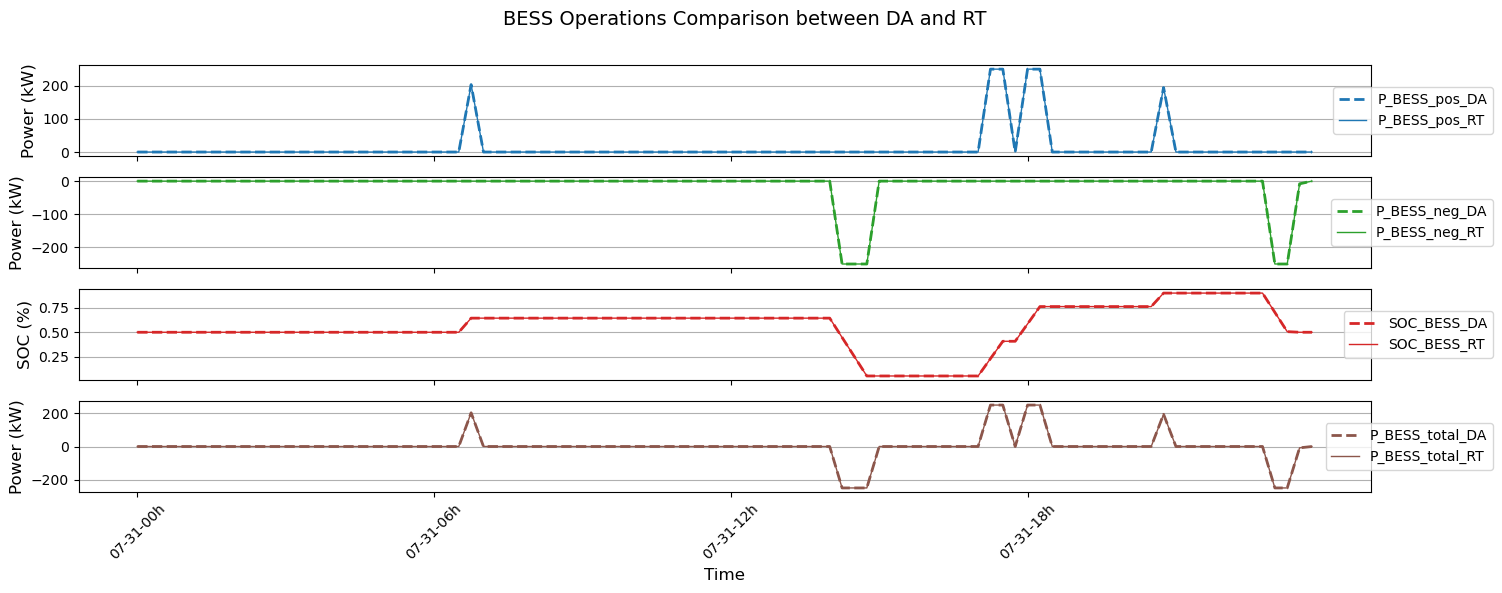

In [ ]:
# Sanity Check: Solver_Outputs_DA and Solver_Outputs_RT_Base should have exactly the same values for bids
keys = ['P_WM_DA_RU_bid', 'P_WM_DA_RD_bid', 'P_WM_DA_SP_bid', 'P_WM_DA_NSP_bid', 'P_WM_DA_EM_bid', 'P_WM_RT_RU_bid', 'P_WM_RT_RD_bid', 'P_WM_RT_SP_bid', 'P_WM_RT_NSP_bid', 'P_WM_RT_EM_bid', 'P_BESS_pos', 'P_BESS_neg', 'SOC_BESS', 'P_WM_pos', 'P_WM_neg']
for key in keys:
    da_values = Solver_Outputs_DA[key]
    rt_values = Solver_Outputs_RT_Base[key]
    if not np.allclose(da_values, rt_values, rtol=1e-3):
        print(f"Mismatch found in {key} between DA and RT results.")
        
# Calculate the real cost of DA and RT implementations
total_cost_DA = Solver_Outputs_DA['Cost_Opt']
total_cost_RT = -sum(Solver_Outputs_RT_Base['Revenue_WM'])
print(f"Total Cost from DA Optimization: ${total_cost_DA:.2f}")
print(f"Total Cost from RT Implementation: ${total_cost_RT:.2f}")

# calculate the battery cycles from DA and RT results
def calculate_battery_cycles(P_BESS_pos, P_BESS_neg, dt_h, C_BESS):
    current_cycle = dt_h * np.sum(P_BESS_pos - P_BESS_neg)
    current_cycles = current_cycle / C_BESS
    return current_cycles
current_cycles_DA = calculate_battery_cycles(Solver_Outputs_DA['P_BESS_pos'], Solver_Outputs_DA['P_BESS_neg'], dt_h, C_BESS)
current_cycles_RT = calculate_battery_cycles(Solver_Outputs_RT_Base['P_BESS_pos'], Solver_Outputs_RT_Base['P_BESS_neg'], dt_h, C_BESS)
print(f"Current Battery Cycles from DA Optimization: {current_cycles_DA:.2f} cycles")
print(f"Current Battery Cycles from RT Implementation: {current_cycles_RT:.2f} cycles")

# plot the comparison of DA and RT bids
figure = plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.plot(t_RT, Solver_Outputs_DA['P_WM_pos'], label='P_WM_pos_DA', color=palette[1], linestyle='--')
plt.plot(t_RT, Solver_Outputs_RT_Base['P_WM_pos'], label='P_WM_pos_RT', color=palette[1], linestyle='-')
plt.xlabel('Time', fontsize=label_fontsize)
plt.ylabel('Power (kW)', fontsize=label_fontsize)
plt.xticks(ticks, tick_labels, rotation=45, fontsize=tick_fontsize)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(t_RT, Solver_Outputs_DA['P_WM_neg'], label='P_WM_neg_DA', color=palette[4], linestyle='--')
plt.plot(t_RT, Solver_Outputs_RT_Base['P_WM_neg'], label='P_WM_neg_RT', color=palette[4], linestyle='-')
plt.xlabel('Time', fontsize=label_fontsize)
plt.ylabel('Power (kW)', fontsize=label_fontsize)
plt.xticks(ticks, tick_labels, rotation=45, fontsize=tick_fontsize)
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.grid()
plt.tight_layout()
# plt.show()
plt.close()

# plot the comparison of DA and RT BESS operations
fig, axs = plt.subplots(4, 1, figsize=(15, 6), sharex=True)
fig.suptitle('BESS Operations Comparison between DA and RT', fontsize=title_fontsize)

# P_BESS_pos
axs[0].plot(t_RT, Solver_Outputs_DA['P_BESS_pos'], label='P_BESS_pos_DA', color=palette[0], linestyle='--', linewidth=2)
axs[0].plot(t_RT, Solver_Outputs_RT_Base['P_BESS_pos'], label='P_BESS_pos_RT', color=palette[0], linestyle='-', linewidth=1)
axs[0].set_ylabel('Power (kW)', fontsize=label_fontsize)
axs[0].legend(loc='center right', fontsize=10, bbox_to_anchor=(1.1, 0.5))
axs[0].grid(axis='y')

# P_BESS_neg
axs[1].plot(t_RT, Solver_Outputs_DA['P_BESS_neg'], label='P_BESS_neg_DA', color=palette[2], linestyle='--', linewidth=2)
axs[1].plot(t_RT, Solver_Outputs_RT_Base['P_BESS_neg'], label='P_BESS_neg_RT', color=palette[2], linestyle='-', linewidth=1)
axs[1].set_ylabel('Power (kW)', fontsize=label_fontsize)
axs[1].legend(loc='center right', fontsize=10, bbox_to_anchor=(1.1, 0.5))
axs[1].grid(axis='y')

# P_BESS_total
axs[3].plot(t_RT, Solver_Outputs_DA['P_BESS_pos'] + Solver_Outputs_DA['P_BESS_neg'], label='P_BESS_total_DA', color=palette[5], linestyle='--', linewidth=2)
axs[3].plot(t_RT, Solver_Outputs_RT_Base['P_BESS_pos'] + Solver_Outputs_RT_Base['P_BESS_neg'], label='P_BESS_total_RT', color=palette[5], linestyle='-', linewidth=1)
axs[3].set_ylabel('Power (kW)', fontsize=label_fontsize)
axs[3].set_xlabel('Time', fontsize=label_fontsize)
axs[3].legend(loc='center right', fontsize=10, bbox_to_anchor=(1.1, 0.5))
axs[3].grid(axis='y')

# SOC_BESS
axs[2].plot(t_RT, Solver_Outputs_DA['SOC_BESS'], label='SOC_BESS_DA', color=palette[3], linestyle='--', linewidth=2)
axs[2].plot(t_RT, Solver_Outputs_RT_Base['SOC_BESS'], label='SOC_BESS_RT', color=palette[3], linestyle='-', linewidth=1)
axs[2].set_ylabel('SOC (%)', fontsize=label_fontsize)
axs[2].legend(loc='center right', fontsize=10, bbox_to_anchor=(1.1, 0.5))
axs[2].grid(axis='y')

for ax in axs:
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, rotation=45, fontsize=tick_fontsize)

plt.tight_layout(rect=[0, 0, 1, 0.97])
dir = 'Results/BESS_test/'
os.makedirs(dir, exist_ok=True)
plt.savefig(dir + 'BESS_Operations.png', dpi=300)
plt.show()
plt.close()



